In [1]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import glob
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union
import shutil

In [2]:
local_dataset_dir = '/kaggle/working/dronecam'

In [3]:
train_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-train'
val_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val'
test_dev_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev'
test_dir = '/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-challenge'

In [4]:
train_output_dir = '/kaggle/working/dronecam/dronecam-v1-train'
val_output_dir = '/kaggle/working/dronecam/dronecam-v1-val'
test_dev_output_dir = '/kaggle/working/dronecam/dronecam-v1-test-dev'
test_output_dir = '/kaggle/working/dronecam/dronecam-v1-test-challenge'

In [5]:
old_class_names = {
  0: "pedestrian",
  1: "people",
  2: "bicycle",
  3: "car",
  4: "van",
  5: "truck",
  6: "tricycle",
  7: "awning-tricycle",
  8: "bus",
  9: "motor"
}
v1_class_names = {
    0: "human",
    1: "car"
}
class_name_mapping_old_to_v1_name = {
    "pedestrian": "human",
    "people": "human",
    "car": "car"
}
class_name_mapping_old_to_v1 = {
    0: 0,
    1: 0,
    3: 1
}

In [16]:
def prepare_labelled_df(dataset_path: str, type: Union["training", "val", "test-dev"]) -> pd.DataFrame:
    files = glob.glob(f'{dataset_path}/labels/*.txt')
    rows = []
    for f in tqdm(files, f'Loading {type} annotations'):
        label_file = Path(f)
        image_id = label_file.stem
        img_file = f.replace("labels", "images").replace(".txt", ".jpg")
        if not Path(img_file).exists():
            continue
        img = cv2.imread(img_file)
        h, w = img.shape[:2]
        
        df = pd.read_csv(f, sep=" ", names=["class", "x_center", "y_center", "width", "height"])
        df['file'] = f
        df['image_id'] = image_id
        df['class'] = df['class'].map(lambda i: class_name_mapping_old_to_v1[i] if i in class_name_mapping_old_to_v1.keys() else 2)
        df = df[(df['class'] >= 0) & (df['class'] <= 1)]
        df['cn'] = df['class'].map(lambda i: v1_class_names[i] if i in v1_class_names.keys() else None)
        df['img_width'] = w
        df['img_height'] = h
        df['box_width_px'] = df['width'] * w
        df['box_width_r'] = df['box_width_px'].round().astype(int)
        df['box_height_px'] = df['height'] * h
        df['box_height_r'] = df['box_height_px'].round().astype(int)
        df['area_px'] = df['box_width_px'] * df['box_height_px']
        df['area_int'] = df['box_width_r'] * df['box_height_r']

        df.drop_duplicates(inplace=True)
        df = df.dropna()
        
        rows.append(df)
        
    return pd.concat(rows, ignore_index=True)

In [42]:
train_df = prepare_labelled_df(train_dir, "training")
val_df = prepare_labelled_df(val_dir, "val")
test_dev_df = prepare_labelled_df(test_dev_dir, "test")

Loading test annotations: 100%|██████████| 1610/1610 [00:32<00:00, 49.11it/s]


In [39]:
def class_balance_check(df: pd.DataFrame, hue: str = None) -> None:
    ax = sns.histplot(
        data=df,
        x = 'cn',
        # order=df['cn'].value_counts().index,
        hue=hue,
        multiple='stack',
        kde=False,
        palette='viridis',
        discrete=True
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    plt.show()

/tmp/ipykernel_57/623046231.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(
/tmp/ipykernel_57/623046231.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


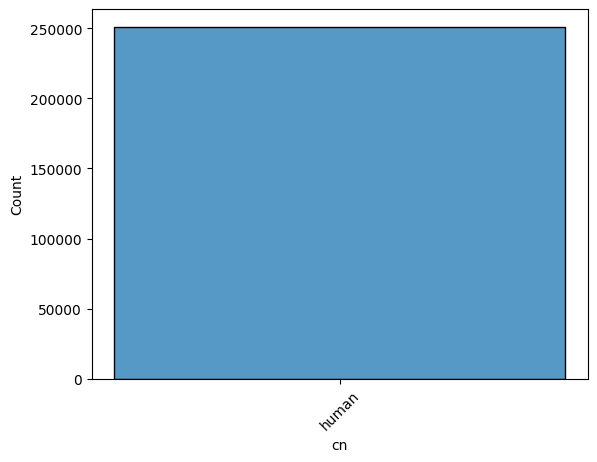

In [43]:
class_balance_check(train_df)

/tmp/ipykernel_57/623046231.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(
/tmp/ipykernel_57/623046231.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


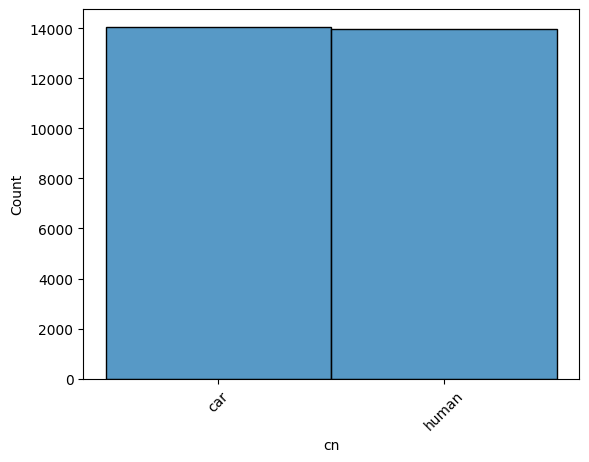

/tmp/ipykernel_57/623046231.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(
/tmp/ipykernel_57/623046231.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


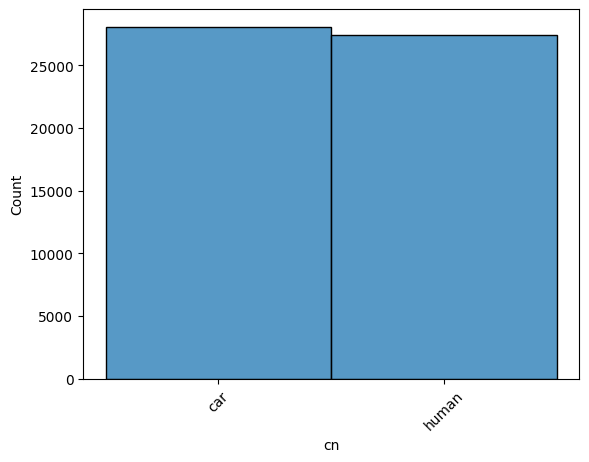

In [14]:
class_balance_check(val_df)
class_balance_check(test_dev_df)

In [14]:
train_df.dropna(inplace=True)

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 251263 entries, 0 to 343204
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   class          251263 non-null  int64  
 1   x_center       251263 non-null  float64
 2   y_center       251263 non-null  float64
 3   width          251263 non-null  float64
 4   height         251263 non-null  float64
 5   file           251263 non-null  object 
 6   cn             251263 non-null  object 
 7   img_width      251263 non-null  int64  
 8   img_height     251263 non-null  int64  
 9   box_width_px   251263 non-null  float64
 10  box_width_r    251263 non-null  int64  
 11  box_height_px  251263 non-null  float64
 12  box_height_r   251263 non-null  int64  
 13  area_px        251263 non-null  float64
 14  area_int       251263 non-null  int64  
dtypes: float64(7), int64(6), object(2)
memory usage: 30.7+ MB


In [54]:
def trim_unnecessary_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df[(df["box_width_r"] > 0) & (df["box_height_r"] > 0)]
    df = df.dropna()
    return df

In [ ]:
train_df

In [55]:
def export_dataset(df: pd.DataFrame, root_dir: str) -> pd.DataFrame:
    root_path = Path(root_dir)
    root_path.mkdir(parents=True, exist_ok=True)
    (root_path / "images").mkdir(parents=True, exist_ok=True)
    (root_path / "labels").mkdir(parents=True, exist_ok=True)
    for file, group in tqdm(df.groupby("file"), f"Exporting data"):
        img_id = Path(file).stem
        label_dest = Path(root_dir) / "labels" / f'{img_id}.txt'
        image_dest = Path(root_dir) / "images" / f'{img_id}.jpg'
        image_src = file.replace('labels', 'images').replace(".txt", ".jpg")
        shutil.copy(image_src, image_dest)
        with open(label_dest, 'w') as f:
            for _, row in group.iterrows():
                f.write(
                    f"{row['class']} " +
                    f"{row["x_center"]} {row['y_center']} " + 
                    f"{row['width']} {row['height']}\n"
                )

In [56]:
export_dataset(train_df, train_output_dir)
export_dataset(val_df, val_output_dir)
export_dataset(test_dev_df, test_dev_output_dir)

Exporting data: 100%|██████████| 1603/1603 [00:09<00:00, 173.98it/s]


In [20]:
def export_image_only_dataset(root_output_dir: str, source_dir: str) -> None:
    root_path = Path(root_output_dir)
    source_path = Path(source_dir)
    root_path.mkdir(parents=True, exist_ok=True)
    dest_image_dir = root_path / "images"
    src_image_dir = source_path / "images"
    if (dest_image_dir).exists():
        shutil.rmtree(dest_image_dir)
    shutil.copytree(src_image_dir, dest_image_dir)

In [21]:
export_image_only_dataset(test_output_dir, test_dir)

In [22]:
dataset_v1_conf = """
# Dronecam Dataset Configuration
path: ./dronecam-v1
train: dronecam-v1-train/images
val: dronecam-v1-val/images
test: dronecam-v1-test-dev/images

# Number of classes
nc: 2

# Class names
names:
  0: human
  1: car
"""

In [23]:
with open(Path(local_dataset_dir) / "dronecam_v1.yaml", 'w') as f:
    f.write(dataset_v1_conf)

In [57]:
# upload_data
import kagglehub

handle = 'kamrulhasan12345/dronecam-v1'
local_dataset_dir = '/kaggle/working/dronecam'

kagglehub.dataset_upload(handle, local_dataset_dir, version_notes='fix: fixed directory names')

Uploading Dataset https://api.kaggle.com/datasets/kamrulhasan12345/dronecam-v1 ...
More than 50 files detected, creating a zip archive...
Starting upload for file /tmp/tmpo58jow6a/archive.zip


Uploading: 100%|██████████| 2.26G/2.26G [00:26<00:00, 86.5MB/s]

Upload successful: /tmp/tmpo58jow6a/archive.zip (2GB)


Your dataset version has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/kamrulhasan12345/dronecam-v1


In [53]:
train_df['cn'].value_counts()

cn
car      144867
human    106396
Name: count, dtype: int64

In [51]:
train_df['cn'] = train_df['class'].map(lambda i: v1_class_names[i] if i in v1_class_names.keys() else None)
val_df['cn'] = val_df['class'].map(lambda i: v1_class_names[i] if i in v1_class_names.keys() else None)
test_dev_df['cn'] = test_dev_df['class'].map(lambda i: v1_class_names[i] if i in v1_class_names.keys() else None)

In [9]:
train_df.duplicated(keep=False)

0         False
1         False
2         False
3         False
4         False
          ...  
251258    False
251259    False
251260    False
251261    False
251262    False
Length: 251263, dtype: bool

In [15]:
duplicates = train_df[train_df.duplicated(keep=False)]
print(duplicates['file'].str[100:-1])

46404     999987_00000_d_0000049.tx
46409     999987_00000_d_0000049.tx
146088    000137_02220_d_0000163.tx
146103    000137_02220_d_0000163.tx
212221    000140_00118_d_0000002.tx
212286    000140_00118_d_0000002.tx
Name: file, dtype: object
